In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('SimpleLR_Dataset(Sheet1).csv')

In [ ]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


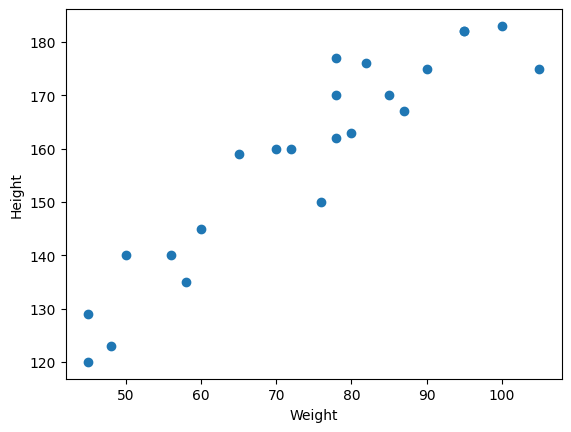

In [ ]:
#scatter plot
plt.scatter(df.Weight,df.Height)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [ ]:
# correlation between features
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [ ]:
#split features into independent and dependent features
#independent features should be dataframe or 2D array
#dependent feature can be in series or a 1D array
X=df[['Weight']]
y=df['Height']


In [ ]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [ ]:
X_train.shape

(17, 1)

In [ ]:
#standardization Mean=0 and std dv=1
from sklearn.preprocessing import StandardScaler
sc=StandardScaler() #applies z-score
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)


In [ ]:
#apply linear regression and make the model learn the relationship between x_train and y_train
#y=wx+b
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train) #X_train should always be a 2D array

LinearRegression()

In [ ]:
print ("Coefficient:",lr.coef_)  #it is slope

Coefficient: [17.2982057]


In [ ]:
print ("Intercept:",lr.intercept_ ) #intercept b


Intercept: 156.47058823529412


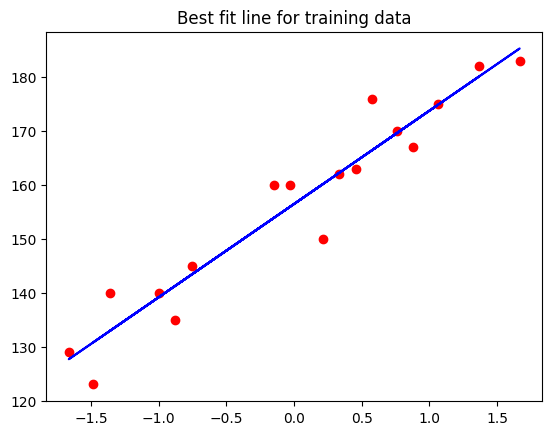

In [ ]:
#plot best fit line for training data
plt.scatter(X_train,y_train,color='red')
plt.plot(X_train,lr.predict(X_train),color='blue')
plt.title('Best fit line for training data')
plt.show()


In [ ]:
#prediction for test data
y_pred=lr.predict(X_test)



In [ ]:
#performance matrix
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))
print("Root Mean Squared Error:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score:",r2_score(y_test,y_pred))


Mean Absolute Error: 9.66512588679501
Mean Squared Error: 114.84069295228699
Root Mean Squared Error: 10.716374991212605
R2 Score: 0.7360826717981276


In [ ]:
#Adjusted R2
#1-[(1-R2)*(n-1)/(n-k-1)]
#n=number of observations
#k=number of predictor variables
1-((1-r2_score(y_test,y_pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.6701033397476595

In [21]:
#prediction for new data
lr.predict(sc.transform([[70]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([153.88159699])